In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
DATA_PATH = r"D:\projects\AI-Stock-Analytics-System\data\processed"

df = pd.read_csv(
    os.path.join(DATA_PATH, "cleaned_stock_data.csv")
)

In [3]:
df.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2005-01-03,238.508957,239.486735,236.588314,238.508957,1031091.0,ACC
1,2005-01-04,245.318558,246.785235,238.299487,239.556627,2377765.0,ACC
2,2005-01-05,243.432800,250.661408,234.912141,245.143927,3886135.0,ACC
3,2005-01-06,239.975601,248.915312,237.461301,243.048626,2954242.0,ACC
4,2005-01-07,244.794708,247.797887,240.255006,247.797887,1817394.0,ACC


In [4]:
df.shape


(481533, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481533 entries, 0 to 481532
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Date    481533 non-null  object 
 1   Close   481533 non-null  float64
 2   High    481533 non-null  float64
 3   Low     481533 non-null  float64
 4   Open    481533 non-null  float64
 5   Volume  481533 non-null  float64
 6   Ticker  481533 non-null  object 
dtypes: float64(5), object(2)
memory usage: 25.7+ MB


In [6]:
df["Date"] = pd.to_datetime(df["Date"])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481533 entries, 0 to 481532
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   Date    481533 non-null  datetime64[ns]
 1   Close   481533 non-null  float64       
 2   High    481533 non-null  float64       
 3   Low     481533 non-null  float64       
 4   Open    481533 non-null  float64       
 5   Volume  481533 non-null  float64       
 6   Ticker  481533 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 25.7+ MB


In [8]:
df = df.sort_values(
    by=["Ticker", "Date"]
).reset_index(drop=True)

In [9]:
df.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2005-01-03,238.508957,239.486735,236.588314,238.508957,1031091.0,ACC
1,2005-01-04,245.318558,246.785235,238.299487,239.556627,2377765.0,ACC
2,2005-01-05,243.432800,250.661408,234.912141,245.143927,3886135.0,ACC
3,2005-01-06,239.975601,248.915312,237.461301,243.048626,2954242.0,ACC
4,2005-01-07,244.794708,247.797887,240.255006,247.797887,1817394.0,ACC


In [10]:
df.groupby("Ticker")

In [11]:
df["Daily_Return"] = (
    df.groupby("Ticker")["Close"]
      .pct_change()
)

In [12]:
df[["Ticker", "Date", "Close", "Daily_Return"]].head(15)

,Ticker,Date,Close,Daily_Return
0,ACC,2005-01-03,238.508957,NaN
1,ACC,2005-01-04,245.318558,0.028551
2,ACC,2005-01-05,243.432800,-0.007687
3,ACC,2005-01-06,239.975601,-0.014202
4,ACC,2005-01-07,244.794708,0.020082
5,ACC,2005-01-10,240.953522,-0.015691
6,ACC,2005-01-11,233.305832,-0.031739
7,ACC,2005-01-12,232.712173,-0.002545
8,ACC,2005-01-13,245.039215,0.052971
9,ACC,2005-01-14,240.778870,-0.017386


In [13]:
df[["Ticker", "Date", "Close", "Daily_Return"]].tail(15)

,Ticker,Date,Close,Daily_Return
481518,ZYDUSLIFE,2026-07-07,1151.964844,0.004443
481519,ZYDUSLIFE,2026-07-08,1146.969238,-0.004337
481520,ZYDUSLIFE,2026-07-09,1157.959473,0.009582
481521,ZYDUSLIFE,2026-07-10,1149.766846,-0.007075
481522,ZYDUSLIFE,2026-07-13,1130.284302,-0.016945
481523,ZYDUSLIFE,2026-07-14,1132.582153,0.002033
481524,ZYDUSLIFE,2026-07-15,1155.861328,0.020554
481525,ZYDUSLIFE,2026-07-16,1152.864014,-0.002593
481526,ZYDUSLIFE,2026-07-17,1142.673096,-0.008840
481527,ZYDUSLIFE,2026-07-20,1147.968384,0.004634


In [14]:
df["MA5"] = (
    df.groupby("Ticker")["Close"]
      .transform(lambda x: x.rolling(window=5).mean())
)

In [15]:
df[["Ticker", "Date", "Close", "MA5"]].head(10)

,Ticker,Date,Close,MA5
0,ACC,2005-01-03,238.508957,NaN
1,ACC,2005-01-04,245.318558,NaN
2,ACC,2005-01-05,243.432800,NaN
3,ACC,2005-01-06,239.975601,NaN
4,ACC,2005-01-07,244.794708,242.406125
5,ACC,2005-01-10,240.953522,242.895038
6,ACC,2005-01-11,233.305832,240.492493
7,ACC,2005-01-12,232.712173,238.348367
8,ACC,2005-01-13,245.039215,239.361090
9,ACC,2005-01-14,240.778870,238.557922


In [16]:
df["MA10"] = (
    df.groupby("Ticker")["Close"]
      .transform(lambda x: x.rolling(window=10).mean())
)

In [17]:
df["MA20"] = (
    df.groupby("Ticker")["Close"]
      .transform(lambda x: x.rolling(window=20).mean())
)

In [18]:
df["MA50"] = (
    df.groupby("Ticker")["Close"]
      .transform(lambda x: x.rolling(window=50).mean())
)

In [19]:
df[["Ticker","Date","Close","MA5","MA10","MA20","MA50"]].head(60)

,Ticker,Date,Close,MA5,MA10,MA20,MA50
0,ACC,2005-01-03,238.508957,NaN,NaN,NaN,NaN
1,ACC,2005-01-04,245.318558,NaN,NaN,NaN,NaN
2,ACC,2005-01-05,243.432800,NaN,NaN,NaN,NaN
3,ACC,2005-01-06,239.975601,NaN,NaN,NaN,NaN
4,ACC,2005-01-07,244.794708,242.406125,NaN,NaN,NaN
5,ACC,2005-01-10,240.953522,242.895038,NaN,NaN,NaN
6,ACC,2005-01-11,233.305832,240.492493,NaN,NaN,NaN
7,ACC,2005-01-12,232.712173,238.348367,NaN,NaN,NaN
8,ACC,2005-01-13,245.039215,239.361090,NaN,NaN,NaN
9,ACC,2005-01-14,240.778870,238.557922,240.482024,NaN,NaN


In [20]:
df["EMA20"] = (df.groupby("Ticker")["Close"].transform(lambda x: x.ewm(span=20,
adjust=False).mean()))

In [21]:
df[["Ticker","Date","Close","MA20","EMA20"]].head(30)

,Ticker,Date,Close,MA20,EMA20
0,ACC,2005-01-03,238.508957,NaN,238.508957
1,ACC,2005-01-04,245.318558,NaN,239.157490
2,ACC,2005-01-05,243.432800,NaN,239.564663
3,ACC,2005-01-06,239.975601,NaN,239.603800
4,ACC,2005-01-07,244.794708,NaN,240.098172
5,ACC,2005-01-10,240.953522,NaN,240.179634
6,ACC,2005-01-11,233.305832,NaN,239.524986
7,ACC,2005-01-12,232.712173,NaN,238.876147
8,ACC,2005-01-13,245.039215,NaN,239.463106
9,ACC,2005-01-14,240.778870,NaN,239.588416


In [22]:
# Calculate price change
delta = df.groupby("Ticker")["Close"].diff()
# Positive changes (gains)
gain = delta.where(delta > 0, 0)
# Negative changes (losses)
loss = -delta.where(delta < 0, 0)
# Average gain over 14 days
avg_gain = gain.groupby(df["Ticker"]).transform(
    lambda x: x.rolling(14).mean())
# Average loss over 14 days
avg_loss = loss.groupby(df["Ticker"]).transform(
    lambda x: x.rolling(14).mean())
# Relative Strength
rs = avg_gain / avg_loss
# RSI
df["RSI"] = 100 - (100 / (1 + rs))

In [23]:
df[["Ticker","Date","Close","RSI"]].head(30)

,Ticker,Date,Close,RSI
0,ACC,2005-01-03,238.508957,NaN
1,ACC,2005-01-04,245.318558,NaN
2,ACC,2005-01-05,243.432800,NaN
3,ACC,2005-01-06,239.975601,NaN
4,ACC,2005-01-07,244.794708,NaN
5,ACC,2005-01-10,240.953522,NaN
6,ACC,2005-01-11,233.305832,NaN
7,ACC,2005-01-12,232.712173,NaN
8,ACC,2005-01-13,245.039215,NaN
9,ACC,2005-01-14,240.778870,NaN


In [24]:
df["EMA12"] = (
    df.groupby("Ticker")["Close"]
      .transform(
          lambda x: x.ewm(
              span=12,
              adjust=False
          ).mean()
      )
)

In [25]:
df["EMA26"] = (
    df.groupby("Ticker")["Close"]
      .transform(
          lambda x: x.ewm(
              span=26,
              adjust=False
          ).mean()
      )
)

In [26]:
df["MACD"] = df["EMA12"] - df["EMA26"]

In [27]:
df[
    [
        "Ticker",
        "Date",
        "Close",
        "EMA12",
        "EMA26",
        "MACD"
    ]
].head(30)

,Ticker,Date,Close,EMA12,EMA26,MACD
0,ACC,2005-01-03,238.508957,238.508957,238.508957,0.000000
1,ACC,2005-01-04,245.318558,239.556588,239.013372,0.543216
2,ACC,2005-01-05,243.432800,240.152928,239.340737,0.812191
3,ACC,2005-01-06,239.975601,240.125647,239.387764,0.737883
4,ACC,2005-01-07,244.794708,240.843964,239.788278,1.055686
5,ACC,2005-01-10,240.953522,240.860819,239.874593,0.986227
6,ACC,2005-01-11,233.305832,239.698513,239.388018,0.310496
7,ACC,2005-01-12,232.712173,238.623692,238.893511,-0.269819
8,ACC,2005-01-13,245.039215,239.610695,239.348748,0.261947
9,ACC,2005-01-14,240.778870,239.790415,239.454683,0.335732


In [28]:
df["Signal_Line"] = (
    df.groupby("Ticker")["MACD"]
      .transform(
          lambda x: x.ewm(
              span=9,
              adjust=False
          ).mean()
      )
)

In [29]:
df[
    [
        "Ticker",
        "Date",
        "MACD",
        "Signal_Line"
    ]
].head(30)

,Ticker,Date,MACD,Signal_Line
0,ACC,2005-01-03,0.000000,0.000000
1,ACC,2005-01-04,0.543216,0.108643
2,ACC,2005-01-05,0.812191,0.249353
3,ACC,2005-01-06,0.737883,0.347059
4,ACC,2005-01-07,1.055686,0.488784
5,ACC,2005-01-10,0.986227,0.588273
6,ACC,2005-01-11,0.310496,0.532717
7,ACC,2005-01-12,-0.269819,0.372210
8,ACC,2005-01-13,0.261947,0.350158
9,ACC,2005-01-14,0.335732,0.347272


In [30]:
df["MACD_Histogram"] = df["MACD"] - df["Signal_Line"]

In [31]:
df[
    [
        "Ticker",
        "Date",
        "MACD",
        "Signal_Line",
        "MACD_Histogram"
    ]
].head(30)

,Ticker,Date,MACD,Signal_Line,MACD_Histogram
0,ACC,2005-01-03,0.000000,0.000000,0.000000
1,ACC,2005-01-04,0.543216,0.108643,0.434573
2,ACC,2005-01-05,0.812191,0.249353,0.562838
3,ACC,2005-01-06,0.737883,0.347059,0.390824
4,ACC,2005-01-07,1.055686,0.488784,0.566902
5,ACC,2005-01-10,0.986227,0.588273,0.397954
6,ACC,2005-01-11,0.310496,0.532717,-0.222222
7,ACC,2005-01-12,-0.269819,0.372210,-0.642029
8,ACC,2005-01-13,0.261947,0.350158,-0.088210
9,ACC,2005-01-14,0.335732,0.347272,-0.011541


In [32]:
rolling_std = (
    df.groupby("Ticker")["Close"]
      .transform(
          lambda x: x.rolling(20).std()
      )
)

In [33]:
df["Upper_Band"] = df["MA20"] + (2 * rolling_std)
df["Lower_Band"] = df["MA20"] - (2 * rolling_std)

In [34]:
df[
    [
        "Ticker",
        "Date",
        "Close",
        "MA20",
        "Upper_Band",
        "Lower_Band"
    ]
].head(30)

,Ticker,Date,Close,MA20,Upper_Band,Lower_Band
0,ACC,2005-01-03,238.508957,NaN,NaN,NaN
1,ACC,2005-01-04,245.318558,NaN,NaN,NaN
2,ACC,2005-01-05,243.432800,NaN,NaN,NaN
3,ACC,2005-01-06,239.975601,NaN,NaN,NaN
4,ACC,2005-01-07,244.794708,NaN,NaN,NaN
5,ACC,2005-01-10,240.953522,NaN,NaN,NaN
6,ACC,2005-01-11,233.305832,NaN,NaN,NaN
7,ACC,2005-01-12,232.712173,NaN,NaN,NaN
8,ACC,2005-01-13,245.039215,NaN,NaN,NaN
9,ACC,2005-01-14,240.778870,NaN,NaN,NaN


In [35]:
df.head()

,Date,Close,High,Low,Open,Volume,Ticker,Daily_Return,MA5,MA10,...,MA50,EMA20,RSI,EMA12,EMA26,MACD,Signal_Line,MACD_Histogram,Upper_Band,Lower_Band
0,2005-01-03,238.508957,239.486735,236.588314,238.508957,1031091.0,ACC,NaN,NaN,NaN,...,NaN,238.508957,NaN,238.508957,238.508957,0.000000,0.000000,0.000000,NaN,NaN
1,2005-01-04,245.318558,246.785235,238.299487,239.556627,2377765.0,ACC,0.028551,NaN,NaN,...,NaN,239.157490,NaN,239.556588,239.013372,0.543216,0.108643,0.434573,NaN,NaN
2,2005-01-05,243.432800,250.661408,234.912141,245.143927,3886135.0,ACC,-0.007687,NaN,NaN,...,NaN,239.564663,NaN,240.152928,239.340737,0.812191,0.249353,0.562838,NaN,NaN
3,2005-01-06,239.975601,248.915312,237.461301,243.048626,2954242.0,ACC,-0.014202,NaN,NaN,...,NaN,239.603800,NaN,240.125647,239.387764,0.737883,0.347059,0.390824,NaN,NaN
4,2005-01-07,244.794708,247.797887,240.255006,247.797887,1817394.0,ACC,0.020082,242.406125,NaN,...,NaN,240.098172,NaN,240.843964,239.788278,1.055686,0.488784,0.566902,NaN,NaN


In [36]:
df["Volatility"] = (
    df.groupby("Ticker")["Daily_Return"]
      .transform(
          lambda x: x.rolling(20).std()
      )
)

In [37]:
df[
    [
        "Ticker",
        "Date",
        "Daily_Return",
        "Volatility"
    ]
].head(30)

,Ticker,Date,Daily_Return,Volatility
0,ACC,2005-01-03,NaN,NaN
1,ACC,2005-01-04,0.028551,NaN
2,ACC,2005-01-05,-0.007687,NaN
3,ACC,2005-01-06,-0.014202,NaN
4,ACC,2005-01-07,0.020082,NaN
5,ACC,2005-01-10,-0.015691,NaN
6,ACC,2005-01-11,-0.031739,NaN
7,ACC,2005-01-12,-0.002545,NaN
8,ACC,2005-01-13,0.052971,NaN
9,ACC,2005-01-14,-0.017386,NaN


In [38]:
df["Lag1"] = (
    df.groupby("Ticker")["Close"]
      .shift(1)
)

In [39]:
df["Lag2"] = (
    df.groupby("Ticker")["Close"]
      .shift(2)
)

In [40]:
df["Lag3"] = (
    df.groupby("Ticker")["Close"]
      .shift(3)
)

In [41]:
df[
    [
        "Ticker",
        "Date",
        "Close",
        "Lag1",
        "Lag2",
        "Lag3"
    ]
].head(10)


,Ticker,Date,Close,Lag1,Lag2,Lag3
0,ACC,2005-01-03,238.508957,NaN,NaN,NaN
1,ACC,2005-01-04,245.318558,238.508957,NaN,NaN
2,ACC,2005-01-05,243.432800,245.318558,238.508957,NaN
3,ACC,2005-01-06,239.975601,243.432800,245.318558,238.508957
4,ACC,2005-01-07,244.794708,239.975601,243.432800,245.318558
5,ACC,2005-01-10,240.953522,244.794708,239.975601,243.432800
6,ACC,2005-01-11,233.305832,240.953522,244.794708,239.975601
7,ACC,2005-01-12,232.712173,233.305832,240.953522,244.794708
8,ACC,2005-01-13,245.039215,232.712173,233.305832,240.953522
9,ACC,2005-01-14,240.778870,245.039215,232.712173,233.305832


In [42]:
df.head()


,Date,Close,High,Low,Open,Volume,Ticker,Daily_Return,MA5,MA10,...,EMA26,MACD,Signal_Line,MACD_Histogram,Upper_Band,Lower_Band,Volatility,Lag1,Lag2,Lag3
0,2005-01-03,238.508957,239.486735,236.588314,238.508957,1031091.0,ACC,NaN,NaN,NaN,...,238.508957,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-01-04,245.318558,246.785235,238.299487,239.556627,2377765.0,ACC,0.028551,NaN,NaN,...,239.013372,0.543216,0.108643,0.434573,NaN,NaN,NaN,238.508957,NaN,NaN
2,2005-01-05,243.432800,250.661408,234.912141,245.143927,3886135.0,ACC,-0.007687,NaN,NaN,...,239.340737,0.812191,0.249353,0.562838,NaN,NaN,NaN,245.318558,238.508957,NaN
3,2005-01-06,239.975601,248.915312,237.461301,243.048626,2954242.0,ACC,-0.014202,NaN,NaN,...,239.387764,0.737883,0.347059,0.390824,NaN,NaN,NaN,243.432800,245.318558,238.508957
4,2005-01-07,244.794708,247.797887,240.255006,247.797887,1817394.0,ACC,0.020082,242.406125,NaN,...,239.788278,1.055686,0.488784,0.566902,NaN,NaN,NaN,239.975601,243.432800,245.318558


In [43]:
df["Target_Close"] = (
    df.groupby("Ticker")["Close"]
      .shift(-1)
)

In [44]:
df[
    [
        "Ticker",
        "Date",
        "Close",
        "Target_Close"
    ]
].head(10)

,Ticker,Date,Close,Target_Close
0,ACC,2005-01-03,238.508957,245.318558
1,ACC,2005-01-04,245.318558,243.432800
2,ACC,2005-01-05,243.432800,239.975601
3,ACC,2005-01-06,239.975601,244.794708
4,ACC,2005-01-07,244.794708,240.953522
5,ACC,2005-01-10,240.953522,233.305832
6,ACC,2005-01-11,233.305832,232.712173
7,ACC,2005-01-12,232.712173,245.039215
8,ACC,2005-01-13,245.039215,240.778870
9,ACC,2005-01-14,240.778870,250.556808


In [46]:
df["Future_Return"] = (
    (df.groupby("Ticker")["Close"].shift(-1)- df["Close"])/ df["Close"])

In [48]:
def create_signal(x):
    if x > 0.01:
        return "BUY"
    elif x < -0.01:
        return "SELL"
    else:
        return "HOLD"

In [49]:
df["Target_Signal"] = df["Future_Return"].apply(create_signal)

In [50]:
df[
    [
        "Ticker",
        "Date",
        "Close",
        "Future_Return",
        "Target_Signal"
    ]
].head(15)

,Ticker,Date,Close,Future_Return,Target_Signal
0,ACC,2005-01-03,238.508957,0.028551,BUY
1,ACC,2005-01-04,245.318558,-0.007687,HOLD
2,ACC,2005-01-05,243.432800,-0.014202,SELL
3,ACC,2005-01-06,239.975601,0.020082,BUY
4,ACC,2005-01-07,244.794708,-0.015691,SELL
5,ACC,2005-01-10,240.953522,-0.031739,SELL
6,ACC,2005-01-11,233.305832,-0.002545,HOLD
7,ACC,2005-01-12,232.712173,0.052971,BUY
8,ACC,2005-01-13,245.039215,-0.017386,SELL
9,ACC,2005-01-14,240.778870,0.040610,BUY


In [51]:
df["Future_Return"].describe()

count    481432.000000
mean          0.001197
std           0.160266
min          -0.990858
25%          -0.010630
50%           0.000065
75%           0.011511
max         108.493063
Name: Future_Return, dtype: float64

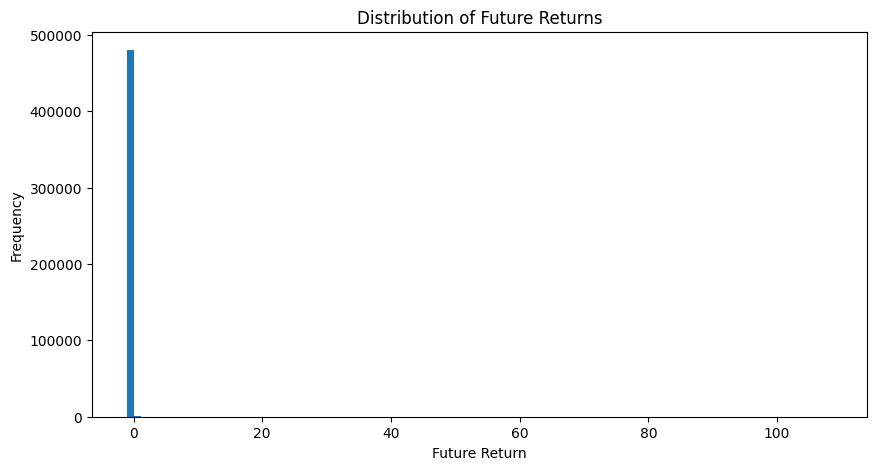

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df["Future_Return"], bins=100)

plt.title("Distribution of Future Returns")
plt.xlabel("Future Return")
plt.ylabel("Frequency")

plt.show()

In [53]:
df["Target_Signal"].value_counts()

Target_Signal
HOLD    222906
BUY     132826
SELL    125801
Name: count, dtype: int64

In [54]:
(
    df["Target_Signal"]
    .value_counts(normalize=True)
    * 100
).round(2)

Target_Signal
HOLD    46.29
BUY     27.58
SELL    26.13
Name: proportion, dtype: float64

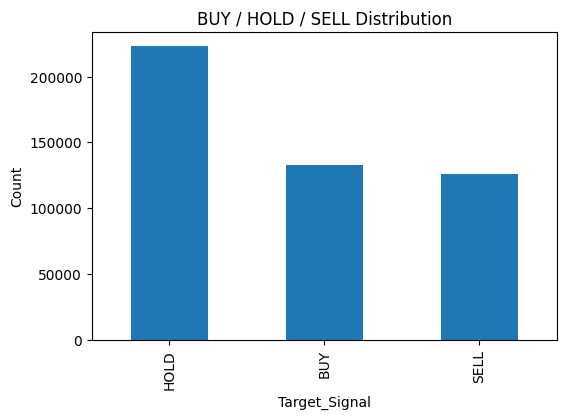

In [55]:
df["Target_Signal"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("BUY / HOLD / SELL Distribution")
plt.ylabel("Count")

plt.show()

In [58]:
df.nlargest(10, "Future_Return")[
    ["Ticker", "Date", "Close", "Target_Close", "Future_Return"]
]

,Ticker,Date,Close,Target_Close,Future_Return
48812,BAJFINANCE,2005-07-27,2.310208,252.951706,108.493063
155279,EICHERMOT,2005-07-27,23.056576,230.565826,9.000003
199119,HINDPETRO,2005-07-27,19.560432,132.032959,5.750002
172494,GRASIM,2005-07-27,149.679230,970.034119,5.480753
236523,IOC,2005-07-27,13.238174,79.429070,5.000002
85816,BPCL,2005-07-27,12.737401,76.424400,5.000000
75168,BIOCON,2005-07-27,31.487194,188.923141,4.999999
161845,GAIL,2005-07-27,14.743541,78.632202,4.333332
96464,CANBK,2005-07-27,28.870667,148.411682,4.140570
149955,DRREDDY,2005-07-27,70.506950,352.534851,4.000001


In [59]:
df.nsmallest(10, "Future_Return")[
    ["Ticker", "Date", "Close", "Target_Close", "Future_Return"]
]

,Ticker,Date,Close,Target_Close,Future_Return
48813,BAJFINANCE,2005-07-28,252.951706,2.312484,-0.990858
44186,BAJAJFINSV,2008-05-23,660.177979,48.534531,-0.926483
155280,EICHERMOT,2005-07-28,230.565826,22.939425,-0.900508
199120,HINDPETRO,2005-07-28,132.032959,18.931452,-0.856616
172495,GRASIM,2005-07-28,970.034119,149.915054,-0.845454
236524,IOC,2005-07-28,79.429070,13.098998,-0.835086
75169,BIOCON,2005-07-28,188.923141,31.888910,-0.831207
85817,BPCL,2005-07-28,76.424400,12.956523,-0.830466
161846,GAIL,2005-07-28,78.632202,14.652768,-0.813654
101790,CHOLAFIN,2005-07-28,114.370224,22.578047,-0.802588


In [60]:
df[
    (df["Date"] >= "2005-07-20") &
    (df["Date"] <= "2005-08-05") &
    (df["Ticker"] == "BAJFINANCE")
][["Date", "Close"]]

,Date,Close
48807,2005-07-20,2.298993
48808,2005-07-21,2.276311
48809,2005-07-22,2.310208
48810,2005-07-25,2.309449
48811,2005-07-26,2.349414
48812,2005-07-27,2.310208
48813,2005-07-28,252.951706
48814,2005-07-29,2.312484
48815,2005-08-01,2.341404
48816,2005-08-02,2.307846


In [61]:
df[
    (df["Future_Return"] > 1) |
    (df["Future_Return"] < -0.8)
].shape

(26, 28)

In [62]:
df[
    (df["Future_Return"] > 1) |
    (df["Future_Return"] < -0.8)
][
    ["Ticker", "Date", "Close", "Target_Close", "Future_Return"]
].sort_values(["Ticker", "Date"])

,Ticker,Date,Close,Target_Close,Future_Return
44186,BAJAJFINSV,2008-05-23,660.177979,48.534531,-0.926483
48812,BAJFINANCE,2005-07-27,2.310208,252.951706,108.493063
48813,BAJFINANCE,2005-07-28,252.951706,2.312484,-0.990858
75168,BIOCON,2005-07-27,31.487194,188.923141,4.999999
75169,BIOCON,2005-07-28,188.923141,31.888910,-0.831207
85816,BPCL,2005-07-27,12.737401,76.424400,5.000000
85817,BPCL,2005-07-28,76.424400,12.956523,-0.830466
96464,CANBK,2005-07-27,28.870667,148.411682,4.140570
101789,CHOLAFIN,2005-07-27,22.874044,114.370224,4.000000
101790,CHOLAFIN,2005-07-28,114.370224,22.578047,-0.802588


In [63]:
outliers = df[
    (df["Future_Return"] > 1) |
    (df["Future_Return"] < -0.8)
]

print("Outliers found:", len(outliers))

Outliers found: 26


In [64]:
outliers.to_csv(
    "D:/projects/AI-Stock-Analytics-System/data/processed/outliers_removed.csv",
    index=False
)

In [65]:
df = df[
    (df["Future_Return"] <= 1) &
    (df["Future_Return"] >= -0.8)
].reset_index(drop=True)

In [66]:
print(df.shape)

(481406, 28)


In [67]:
df["Future_Return"].describe()

count    481406.000000
mean          0.000859
std           0.023613
min          -0.797221
25%          -0.010630
50%           0.000065
75%           0.011509
max           1.000000
Name: Future_Return, dtype: float64

In [68]:
print(df.isnull().sum())

Date                 0
Close                0
High                 0
Low                  0
Open                 0
Volume               0
Ticker               0
Daily_Return       101
MA5                404
MA10               909
MA20              1919
MA50              4949
EMA20                0
RSI               2551
EMA12                0
EMA26                0
MACD                 0
Signal_Line          0
MACD_Histogram       0
Upper_Band        1919
Lower_Band        1919
Volatility        2020
Lag1               101
Lag2               202
Lag3               303
Target_Close         0
Future_Return        0
Target_Signal        0
dtype: int64


In [69]:
df = df.dropna().reset_index(drop=True)

In [70]:
print(df.shape)

(475258, 28)


In [71]:
print(df.isnull().sum())

Date              0
Close             0
High              0
Low               0
Open              0
Volume            0
Ticker            0
Daily_Return      0
MA5               0
MA10              0
MA20              0
MA50              0
EMA20             0
RSI               0
EMA12             0
EMA26             0
MACD              0
Signal_Line       0
MACD_Histogram    0
Upper_Band        0
Lower_Band        0
Volatility        0
Lag1              0
Lag2              0
Lag3              0
Target_Close      0
Future_Return     0
Target_Signal     0
dtype: int64


In [72]:
FEATURE_PATH = r"D:\projects\AI-Stock-Analytics-System\data\final"

os.makedirs(FEATURE_PATH, exist_ok=True)

df.to_csv(
    os.path.join(
        FEATURE_PATH,
        "feature_engineered_stock_data.csv"
    ),
    index=False
)

print("Feature Engineering Completed Successfully!")

Feature Engineering Completed Successfully!
